In [343]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad

In [344]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

model_id = "gpt2"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
print(f"Loaded model: {model_id}")

Loaded model: gpt2


In [345]:
model_id = "gpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model : GPT2LMHeadModel = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer : GPT2TokenizerFast = GPT2TokenizerFast.from_pretrained(model_id)

### Plotting

In [346]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import plotly
import plotly.io as pio
pio.renderers.default = 'iframe'
import plotly.express as px
plotly.offline.init_notebook_mode(connected=True)
import seaborn as sns

cmp = 'algae'
def correlation_heatmap(y_cols, x_cols, full_data):
    '''
    Uses scipy.stats.spearmanr function
    Params:
    y_cols, x_cols: sets of column titles (strings)
    full_data: pandas dataframe that includes all columns listed in y_cols, x_cols
    Returns:
    corr: Spearman correlation coefficient matrix (y_cols = rows, x_cols = cols of matrix)
    fig_corr: annotated plotly heatmap of coefficients
    p: Spearman p-value matrix
    fig_p: annotated plotly heatmap of p-values
    '''
    cols = y_cols+x_cols
    all_correlations = scipy.stats.spearmanr(full_data[cols], nan_policy='omit')
    corr = all_correlations.correlation[:len(y_cols), -len(x_cols):]
    corr = pd.DataFrame(corr)
    corr.columns = x_cols
    corr.index = y_cols

    p = all_correlations.pvalue[:len(y_cols), -len(x_cols):]
    p = pd.DataFrame(p)
    p.columns = x_cols
    p.index = y_cols
    
    fig_corr = px.imshow(corr, text_auto=True, aspect='auto', color_continuous_scale='agsunset')
    fig_r2 = px.imshow(corr**2, text_auto=True, aspect='auto', color_continuous_scale='agsunset')
    fig_p = px.imshow(p, text_auto=True, aspect='auto', color_continuous_scale='gray_r')

    return corr, fig_corr, p, fig_p, fig_r2

In [347]:
def compute_dominance_per_spk(perplexity):
    prev_idx_pp = 0
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in token_list])
    dialog = [tokenizer.decode(token, skip_special_tokens=True) for token in token_list]
    all_values = []
    ppls_p_spk={}
    for idx, match in enumerate(matches):
        if match not in ppls_p_spk:
            ppls_p_spk[match] = []
        for px in range(len(token_list[idx])):
            fin_idx = px + np.sum([len(l) for l in token_list[:idx]], dtype=int)
            ppls_p_spk[match].append(perplexity[fin_idx])
    return ppls_p_spk

In [348]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def rolling_kde_heatmap_with_turns(
    ppls,
    token_list,
    window_size=50,
    step=10,
    bandwidth=0.5,
    vmin=None,
    vmax=None,
    title="[SPK]",
):
    """
    Plots a rolling KDE heatmap over token-level perplexities and marks turn boundaries.
    Optionally returns the KDE densities array.

    Args:
        ppls (List[float]): Flattened token-level perplexities.
        token_list (List[Tensor]): List of per-turn token tensors.
        window_size (int): Window size for KDE.
        step (int): Step size for moving window.
        bandwidth (float): Bandwidth for Gaussian KDE.
        vmin, vmax: Color limits for the heatmap.
        title (str): Title string.
        return_densities (bool): If True, return the densities matrix.

    Returns:
        If return_densities=True, returns the (n_windows x n_bins) KDE matrix.
    """
    ppls = np.array(ppls)
    xs = np.linspace(0, np.nanmax(ppls), 100)
    densities = []

    for i in range(0, len(ppls) - window_size, step):
        window = ppls[i:i + window_size]
        if np.isnan(window).any():
            densities.append(np.zeros_like(xs))  # pad with zeros for alignment
        else:
            kde = gaussian_kde(window, bw_method=bandwidth)
            densities.append(kde(xs))

    densities = np.array(densities)

    # Compute actual token indices of turn ends
    turn_boundaries_token_idx = np.cumsum([len(tok) for tok in token_list])[:-1]
    x_bins = np.arange(0, len(ppls) - window_size, step)
    turn_boundaries_bins = [np.searchsorted(x_bins, tb) for tb in turn_boundaries_token_idx]
    unique_turn_bins = sorted(set(turn_boundaries_bins))

    # Plot
    plt.figure(figsize=(12, 5))
    ax = sns.heatmap(
        densities.T,
        xticklabels=step,
        yticklabels=False,
        cmap="viridis",
        cbar=True,
        vmin=vmin,
        vmax=vmax
    )

    for xb in unique_turn_bins:
        ax.axvline(x=xb, color='white', linestyle='--', linewidth=0.5, alpha=0.7)

    plt.title(f"Rolling KDE Heatmap of PPL for {title}")
    plt.xlabel("Turn Window")
    plt.ylabel("Perplexity Bins")
    plt.tight_layout()
    plt.show()

    return densities


from matplotlib import cm
from matplotlib.colors import Normalize
from IPython.display import HTML

from matplotlib import cm
from matplotlib.colors import Normalize
from IPython.display import HTML

def display_tokens_colored_by_kde(
    token_list,
    ppls,
    densities,
    window_size,
    step,
    tokenizer,
    vmin=None,
    vmax=None,
    cmap_name="viridis"
):
    """
    Colors each token using the rolling KDE heatmap.
    
    Args:
        token_list: List of token tensors per turn.
        ppls: List of token-level perplexities (flattened).
        densities: 2D array of KDE values (n_windows x n_bins).
        window_size: Size of rolling window used for KDE.
        step: Step size used in rolling KDE.
        tokenizer: HF tokenizer.
        vmin, vmax: KDE value scale for coloring.
        cmap_name: Name of matplotlib colormap.

    Returns:
        IPython HTML display of color-coded tokens.
    """
    num_tokens = len(ppls)
    num_windows = densities.shape[0]
    token_kde_scores = np.zeros(num_tokens)
    token_counts = np.zeros(num_tokens)

    # For each window, distribute score across involved tokens
    for win_idx in range(num_windows):
        start = win_idx * step
        end = min(start + window_size, num_tokens)
        # Use max density for that window
        window_density = np.max(densities[win_idx])
        for i in range(start, end):
            token_kde_scores[i] += window_density
            token_counts[i] += 1

    # Normalize per token
    with np.errstate(divide='ignore', invalid='ignore'):
        averaged_scores = np.divide(token_kde_scores, token_counts, out=np.zeros_like(token_kde_scores), where=token_counts != 0)

    # Normalize colors
    norm = Normalize(vmin=vmin if vmin is not None else np.nanmin(averaged_scores),
                     vmax=vmax if vmax is not None else np.nanmax(averaged_scores))
    cmap = cm.get_cmap(cmap_name)

    # Flatten and decode tokens
    flat_tokens = [tok.item() for turn in token_list for tok in turn]
    decoded_tokens = tokenizer.convert_ids_to_tokens(flat_tokens)

    # HTML generation
    html = "<div style='font-family: monospace; line-height: 2;'>"
    for token, score in zip(decoded_tokens, averaged_scores):
        color = cm.colors.rgb2hex(cmap(norm(score)))
        clean_token = token.replace("Ġ", " ").replace("▁", " ").strip()
        html += f"<span style='background-color:{color}; padding:2px 4px; margin:1px; border-radius:3px;'>{clean_token}</span> "
    html += "</div>"

    return HTML(html)


In [349]:
import pandas as pd
import re
import numpy as np

candor_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/CANDOR_gpt2-large/conversations.csv")
candor_df.head()

,file_name,file_content
0,7595d874-c1cb-4aef-918f-3c81f3a84324,<SPK0> this is Yeah. Mhm. Mhm. Yeah. Yeah. Mot...
1,66768810-879d-4e2f-b5f5-ecc67d298104,<SPK0> Uh huh uh huh. Yeah. <SPK1> Yeah. All r...
2,dc3d0ae4-8d20-4d1d-8e0c-82c85a79b26e,<SPK1> Yeah. Right. Mhm. Mhm. Mhm. Okay. Yeah....
3,fb50ccf7-1a5a-4d80-b4f0-d5d1a1fd1135,<SPK0> Hi there and move away. <SPK1> mm. <SPK...
4,73c201ef-8c32-43d4-b642-dcedf4aa5c7f,<SPK0> Yeah. Okay. Yeah. Mhm. Yeah. Mhm Uh huh...


In [350]:
name_file = candor_df.iloc[0]["file_name"]
conversation = candor_df.iloc[0]["file_content"]

In [351]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = conversation.replace("<", "\n<").split("\n")[300:700]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")

Token indices sequence length is longer than the specified maximum sequence length for this model (5045 > 1024). Running this sequence through the model will result in indexing errors


In [352]:
all_data = pd.read_csv(f"../information_exchange_labelling/{candor_df.iloc[0]['file_name']}_candor_ppl.csv")

In [353]:
baselined_ppls_p2_spk = compute_dominance_per_spk(all_data["baselined_p2_scores"])
baselined_ppls_p3_spk = compute_dominance_per_spk(all_data["baselined_p3_scores"])

In [354]:
# Run statistical tests
from scipy import stats
def compute_significance(original_ppls_p_spk):
    spk1_clean = np.array(original_ppls_p_spk["<SPK0>"])
    spk2_clean = np.array(original_ppls_p_spk["<SPK1>"])

    ppl_spk1 = spk1_clean[~np.isnan(spk1_clean)]
    ppl_spk2 = spk2_clean[~np.isnan(spk2_clean)]

    ks_stat, ks_pvalue = stats.ks_2samp(ppl_spk1, ppl_spk2)
    mw_stat, mw_pvalue = stats.mannwhitneyu(ppl_spk1, ppl_spk2, alternative='two-sided')
    tt_stat, tt_pvalue = stats.ttest_ind(ppl_spk1, ppl_spk2, equal_var=False)

    return {
        "Kolmogorov-Smirnov": {"statistic": ks_stat, "p_value": ks_pvalue},
        "Mann-Whitney U": {"statistic": mw_stat, "p_value": mw_pvalue},
        "T-test": {"statistic": tt_stat, "p_value": tt_pvalue}
    }

In [355]:
compute_significance(baselined_ppls_p2_spk), compute_significance(baselined_ppls_p3_spk) 

({'Kolmogorov-Smirnov': {'statistic': 0.04501759164680513,
   'p_value': 0.011716299867592412},
  'Mann-Whitney U': {'statistic': 3105928.5, 'p_value': 0.20099914696931753},
  'T-test': {'statistic': -1.645880597990431, 'p_value': 0.09985074805712257}},
 {'Kolmogorov-Smirnov': {'statistic': 0.15424354429534368,
   'p_value': 1.3704021243709714e-26},
  'Mann-Whitney U': {'statistic': 3385221.5,
   'p_value': 4.4847439169549664e-05},
  'T-test': {'statistic': 8.876509915316959,
   'p_value': 9.521486001388366e-19}})

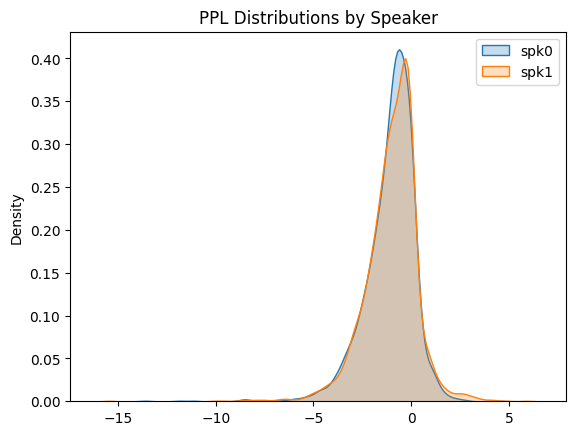

In [356]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(baselined_ppls_p2_spk["<SPK0>"], label="spk0", fill=True)
sns.kdeplot(baselined_ppls_p2_spk["<SPK1>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [357]:
num_turns = 100
upper_limit = np.cumsum([len(token) for token in token_list])[num_turns]

In [358]:
all_data.keys()

Index(['baselined_p1_scores', 'baselined_p2_scores', 'baselined_p3_scores',
       'original_dialog_p1', 'original_dialog_p2', 'original_dialog_p3'],
      dtype='object')

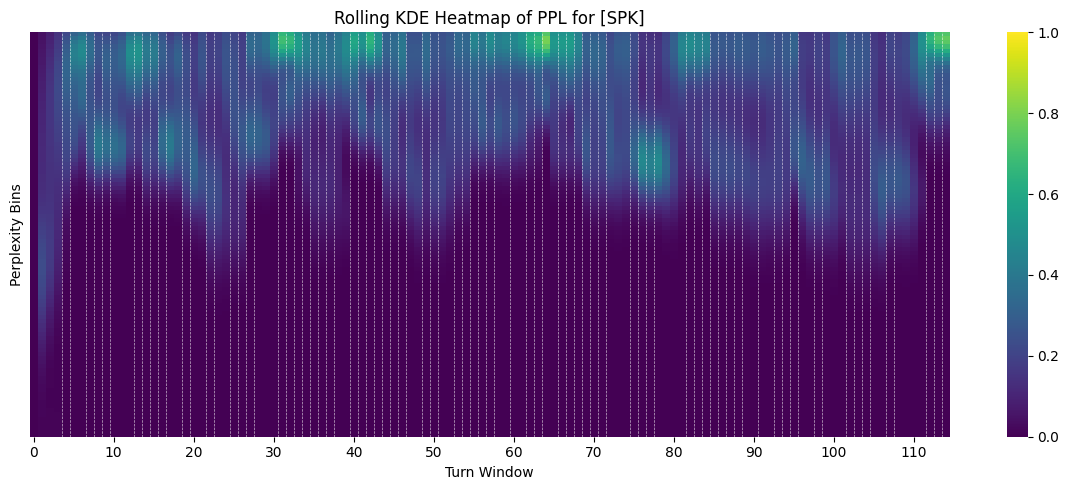

In [359]:
densities = rolling_kde_heatmap_with_turns(token_list=token_list[:num_turns], ppls=all_data["original_dialog_p2"][:upper_limit],vmin=0, vmax=1.0)

In [360]:
html = display_tokens_colored_by_kde(
    token_list=token_list[:num_turns],
    ppls=all_data["original_dialog_p2"][:upper_limit],
    densities=densities,  # output from rolling KDE
    window_size=50,
    step=10,
    tokenizer=tokenizer,
    vmin=0,
    vmax=1.0
)
display(html)

/tmp/ipykernel_848659/2164060071.py:139: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [361]:
tokenizer.decode(encodings.input_ids[0][200:250],skip_special_tokens=True)

". But I'm working on that, you can see like you  <SPK1> right,  <SPK0> see the lamp back there, and then there's like some clothes on the table. Um  <SPK1"

In [362]:
tokenizer.decode(encodings.input_ids[0][4200:4300],skip_special_tokens=True)

".  <SPK1> here and there. Yeah, so like today it's cloudy and that, but from what I understand during the winter the sun will be out, which like to me like I get really lazy and tired and I just don't want to do anything when it's cloudy off.  <SPK0> Yeah. Yeah, no, same here,  <SPK1> Uh huh.  <SPK0> it kind  <SPK1>"

In [363]:
all_data

,baselined_p1_scores,baselined_p2_scores,baselined_p3_scores,original_dialog_p1,original_dialog_p2,original_dialog_p3
0,NaN,NaN,0.000000,NaN,NaN,5.803987
1,1.775190,5.907487,0.000000,8.689340,8.689340,4.423680
2,1.979608,4.870162,0.000000,6.234131,7.461735,3.150732
3,-1.455203,4.122890,0.296505,4.770369,6.564613,2.500506
4,-2.840742,3.376886,0.435235,3.035107,5.682234,2.357071
...,...,...,...,...,...,...
5040,-6.575606,0.066780,-0.086448,0.004365,0.070232,2.790664
5041,-5.947840,-2.536758,-0.055727,3.305077,0.605981,2.716903
5042,-8.889408,-1.754516,-0.066378,0.045958,0.519539,2.180155
5043,-4.405852,-1.277225,0.006343,0.057623,0.460761,2.156072


In [364]:
# AFTER
col_1 = ["original_dialog_p1","original_dialog_p2","original_dialog_p3"]
baselined_p2_scores = np.abs(all_data["original_dialog_p2"])
baselined_p3_scores = np.abs(all_data["original_dialog_p3"])
baselined_p1_scores = np.abs(all_data["original_dialog_p1"])
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [365]:
fig_corr

In [366]:
from sklearn.linear_model import LinearRegression

all_data = all_data.bfill()
P2 = all_data['original_dialog_p2'].to_numpy()
P3 = all_data['original_dialog_p3'].to_numpy()
reg = LinearRegression().fit(P2.reshape(-1, 1), P3)
P3_residual = P3 - reg.predict(P2.reshape(-1, 1))

In [367]:
# AFTER
all_data_res = pd.DataFrame({"original_dialog_p2":P2, "original_dialog_p3": P3_residual})
col_1 = ["original_dialog_p2","original_dialog_p3"]
baselined_p2_scores = np.abs(all_data["original_dialog_p2"])
baselined_p3_scores = np.abs(all_data["original_dialog_p3"])
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_res)

In [368]:
fig_corr

In [369]:
baselined_ppls_p2_spk = compute_dominance_per_spk(all_data_res["original_dialog_p2"])
baselined_ppls_p3_spk = compute_dominance_per_spk(all_data_res["original_dialog_p3"])

In [370]:
compute_significance(baselined_ppls_p2_spk), compute_significance(baselined_ppls_p3_spk) 

({'Kolmogorov-Smirnov': {'statistic': 0.06581997711036829,
   'p_value': 3.447058680423362e-05},
  'Mann-Whitney U': {'statistic': 3038339.0, 'p_value': 0.008472987666027587},
  'T-test': {'statistic': -3.909793882701709,
   'p_value': 9.35875952970319e-05}},
 {'Kolmogorov-Smirnov': {'statistic': 0.18552871867521137,
   'p_value': 2.4713540159218685e-38},
  'Mann-Whitney U': {'statistic': 2641633.0, 'p_value': 6.316043919623753e-25},
  'T-test': {'statistic': -5.7681538255230365,
   'p_value': 8.50035567048496e-09}})

In [371]:
from sklearn.decomposition import PCA

P1 = all_data['original_dialog_p2'].to_numpy()
P2 = all_data['original_dialog_p2'].to_numpy()
P3 = all_data['original_dialog_p3'].to_numpy()

X = np.column_stack([P2, P3])
pca = PCA(n_components=2)
X_orthogonal = pca.fit_transform(X)

In [372]:
P2_pca = X_orthogonal[:,0]
P3_pca = X_orthogonal[:,1]

In [373]:
# AFTER
all_data_pca = pd.DataFrame({"P2_pca": P2_pca, "P3_pca":P3_pca})
col_1 = ["P2_pca","P3_pca"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_pca)

In [374]:
fig_corr

In [375]:
baselined_ppls_p2_spk = compute_dominance_per_spk(all_data_pca["P2_pca"])
baselined_ppls_p3_spk = compute_dominance_per_spk(all_data_pca["P3_pca"])

In [376]:
compute_significance(baselined_ppls_p2_spk), compute_significance(baselined_ppls_p3_spk) 

({'Kolmogorov-Smirnov': {'statistic': 0.048161473656289464,
   'p_value': 0.005576873426966316},
  'Mann-Whitney U': {'statistic': 3073450.0, 'p_value': 0.05081084071861907},
  'T-test': {'statistic': -2.3888452602475043,
   'p_value': 0.016938189230401964}},
 {'Kolmogorov-Smirnov': {'statistic': 0.12812869857669082,
   'p_value': 1.8216354820997353e-18},
  'Mann-Whitney U': {'statistic': 2726988.0, 'p_value': 4.778227096393198e-18},
  'T-test': {'statistic': -6.567032916025903,
   'p_value': 5.650540470932175e-11}})

In [377]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

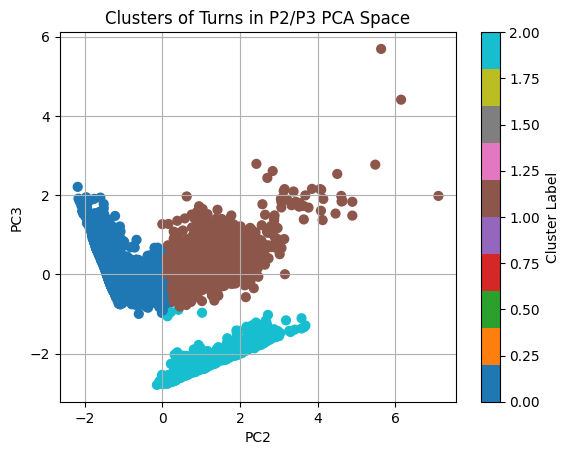

In [378]:
import matplotlib.pyplot as plt
plt.scatter(X_orthogonal[:, 0], X_orthogonal[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()


In [379]:
for cluster_id in np.unique(labels):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(labels == cluster_id)[0]
    for i in indices[:30]:  # first 5 turns
        print(dialog_lines[i])



--- Cluster 0 ---
<SPK1> Oh, 
<SPK0> and then like my own things that 
<SPK1> okay. 
<SPK0> I no longer need, I'm trying 
<SPK1> Rob. 
<SPK1> Oh yeah, 
<SPK0> Yeah. 
<SPK1> I've thought about doing that because I've heard even like you can do it um, through amazon 
<SPK0> Mhm. 
<SPK1> if you get stuff on clearance, any 
<SPK0> Yeah. 
<SPK1> of the stories you go to. Um and I've thought about doing it, but I just was, I think I was concerned that like the shipping and things of 
<SPK0> Right, 
<SPK1> that nature would like make 
<SPK1> it less 
<SPK0> the 
<SPK1> attainable. 
<SPK0> easiest one I've 
<SPK1> It, 
<SPK0> sold on is it's actually doing the best for me right now, 
<SPK0> And you can just download the app on your phone 
<SPK1> thanks. 
<SPK0> and like you know take pictures of the items, you do it like a really brief description and it actually pre fills a lot of the stuff and then 
<SPK1> Yeah. 
<SPK0> you just put it up. Um 
<SPK1> yeah. 
<SPK0> have to have a printer or 

In [380]:
#DBSCAN (finds dense clusters, doesn't require specifying k):
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=5)
labels = db.fit_predict(X)

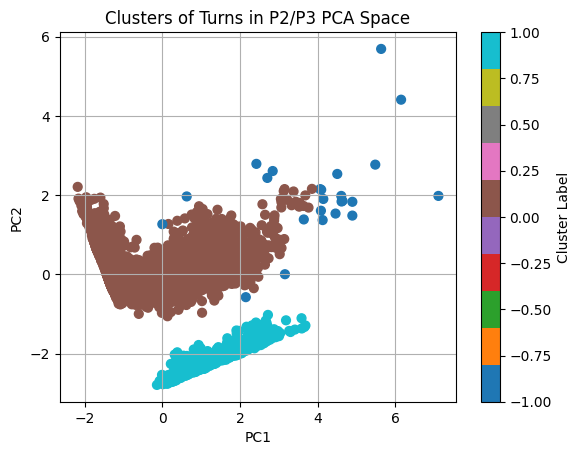

In [381]:
import matplotlib.pyplot as plt
plt.scatter(X_orthogonal[:, 0], X_orthogonal[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

In [382]:
#Gaussian Mixture Model (softer boundaries):
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=0)
labels = gmm.fit_predict(X)

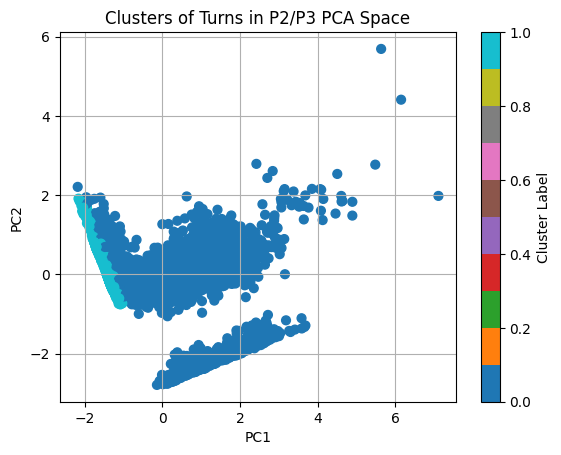

In [383]:
import matplotlib.pyplot as plt
plt.scatter(X_orthogonal[:, 0], X_orthogonal[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

### Labels

In [43]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = conversation.replace("<", "\n<").split("\n")[300:700]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt").input_ids[0].detach().numpy() for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")

In [44]:
directory = "/u/sebono/conversational_dominance/data/external/CANDOR/transcript_audiophile/"
directory_file = directory + f"{name_file}.csv"
transcript_audiophile = pd.read_csv(directory_file).iloc[300:700]
transcript_audiophile.head()

,turn_id,speaker,start,stop,utterance,interval,delta,questions,end_question,overlap,n_words
300,300,5db25a62299961000fc5628d,524.04,524.66,Yeah.,-0.22,0.62,0,False,True,1
301,301,5de90f54a48441037ac21f43,524.54,528.71,it would be ridiculously expensive to try to try,-0.12,4.17,0,False,True,9
302,302,5db25a62299961000fc5628d,528.04,529.06,Yeah. I mean,-0.67,1.02,0,False,True,3
303,303,5de90f54a48441037ac21f43,528.71,530.45,to use that constantly.,-0.35,1.74,0,False,True,4
304,304,5db25a62299961000fc5628d,530.44,531.00,um,-0.01,0.56,0,False,True,1


In [45]:
path_annotations = "/u/sebono/conversational_dominance/data/processed/CANDOR_gpt2-large/affective_labels/"
annotation_file = path_annotations + f"{name_file}.csv"
affective_labels = pd.read_csv(annotation_file)
affective_labels.head()

,timedelta,user_id,f0,intensity,jitter,log_energy,mfcc_0,mfcc_1,mfcc_10,mfcc_11,...,prob_face_anger,prob_face_contempt,prob_face_disgust,prob_face_fear,prob_face_happiness,prob_face_neutral,prob_face_sadness,prob_face_surprise,smile,is_speaking
0,00:00:00,5db25a62299961000fc5628d,148.183666,0.358078,0.738150,-60.111995,-307.14510,73.76912,16.498344,-8.842213,...,0.024918,0.021732,0.015096,0.121907,0.127728,0.314893,0.262391,0.111335,0.0,False
1,00:00:00,5de90f54a48441037ac21f43,NaN,0.000000,NaN,-117.362333,-488.02063,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,00:00:01,5db25a62299961000fc5628d,169.423069,0.803592,2.520832,-24.868979,-203.35008,74.15566,16.471930,-6.074470,...,0.024841,0.016652,0.009746,0.137621,0.134056,0.304708,0.206493,0.165883,0.0,False
3,00:00:01,5de90f54a48441037ac21f43,NaN,0.000000,NaN,-117.362333,-488.02063,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,00:00:02,5db25a62299961000fc5628d,125.282214,0.981204,3.334864,-31.972807,-352.30140,136.10555,2.874847,-1.025165,...,0.029733,0.033620,0.011495,0.053395,0.219319,0.321002,0.198947,0.132489,0.0,False


In [46]:
speakers = list(np.unique(affective_labels["user_id"]))

In [47]:
assert len(transcript_audiophile['utterance']) == len(token_list)

In [48]:
cols = ["prob_face_anger","prob_face_contempt","prob_face_disgust","prob_face_fear","prob_face_happiness","prob_face_neutral","prob_face_sadness","prob_face_surprise","smile"]

In [49]:
transcript_audiophile["tokens"] = token_list

In [315]:
import numpy as np
import pandas as pd
from collections import defaultdict

def assign_words_to_bins(df, bin_size=1.0):
    """
    Assigns words to time bins based on uniform spread over the utterance duration.
    Ensures all bins from time 0 to max stop are represented.

    Returns:
        pd.DataFrame: each bin with its start time, assigned words, and count.
    """
    bin_tok = defaultdict(list)
    bin_ppl = defaultdict(list)
    tok_len = 0
    
    for _, row in df.iterrows():
        start = row["start"]
        stop = row["stop"]
        duration = stop - start

        if duration <= 0 or pd.isna(start) or pd.isna(stop):
            continue

        tokens = row["tokens"]
        n_tokens = len(tokens)
        
        if n_tokens == 0:
            continue

        # Compute per-word time positions assuming uniform spread
        tok_times = np.linspace(start, stop, n_tokens + 1)
        for i, tok in enumerate(tokens):
            tok_start = tok_times[i]
            tok_end = tok_times[i + 1]

            bin_start_idx = int(np.floor(tok_start / bin_size))
            bin_end_idx = int(np.floor(tok_end / bin_size))

            for b in range(bin_start_idx, bin_end_idx + 1):
                bin_tok[b].append(tok)
                bin_ppl[b].append(tok_len + i)

        tok_len += n_tokens
    # Determine full range of bins
    max_bin = int(np.ceil(df["stop"].max() / bin_size))
    all_bins = list(range(max_bin + 1))

    # Construct DataFrame with all bins, filling empty ones with []
    bins_df = pd.DataFrame([
        {
            "time_bin": b,
            "start_time": b * bin_size,
            "end_time": (b + 1) * bin_size,
            "words": tokenizer.decode(torch.tensor(bin_tok[b]), skip_special_tokens=True),
            "ppl": bin_ppl[b],
            "n_tok": len(bin_tok[b])
        }
        for b in all_bins
    ])

    return bins_df

In [316]:
assert np.cumsum([len(l) for l in transcript_audiophile["tokens"]])[-1] == len(all_data_pca["P2_pca"])

In [317]:
affective_labels["timedelta"] = pd.to_timedelta(affective_labels["timedelta"])
affective_labels["time_bin"] = affective_labels["timedelta"].dt.total_seconds().astype(int)

In [318]:
affective_labels_spk1 = affective_labels[affective_labels['user_id']==speakers[0]][cols].reset_index()
affective_labels_spk2 = affective_labels[affective_labels['user_id']==speakers[1]][cols].reset_index()
assert affective_labels_spk2.shape == affective_labels_spk1.shape

In [319]:
combined_df = pd.concat([bins_df.reset_index(drop=True), affective_labels_spk1.iloc[:bins_df.shape[0]].reset_index(drop=True)], axis=1)
combined_df

,time_bin,start_time,end_time,words,ppl,n_tok,index,prob_face_anger,prob_face_contempt,prob_face_disgust,prob_face_fear,prob_face_happiness,prob_face_neutral,prob_face_sadness,prob_face_surprise,smile
0,0,0.0,1.0,,[],0,0,0.024918,0.021732,0.015096,0.121907,0.127728,0.314893,0.262391,0.111335,0.0
1,1,1.0,2.0,,[],0,2,0.024841,0.016652,0.009746,0.137621,0.134056,0.304708,0.206493,0.165883,0.0
2,2,2.0,3.0,,[],0,4,0.029733,0.033620,0.011495,0.053395,0.219319,0.321002,0.198947,0.132489,0.0
3,3,3.0,4.0,,[],0,6,0.020786,0.029500,0.009269,0.054705,0.178884,0.367249,0.130227,0.209381,0.0
4,4,4.0,5.0,,[],0,8,0.030033,0.029007,0.005516,0.024621,0.103434,0.533000,0.215386,0.059003,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1232,1232,1232.0,1233.0,0> Uh,"[5039, 5040, 5041]",3,2464,0.025422,0.006563,0.008671,0.040321,0.026513,0.603602,0.212368,0.076541,0.0
1233,1233,1233.0,1234.0,Uh huh,"[5041, 5042]",2,2466,0.014125,0.016255,0.024359,0.106858,0.194446,0.269486,0.147353,0.227117,0.0
1234,1234,1234.0,1235.0,huh.,"[5042, 5043, 5044]",3,2468,0.016587,0.024803,0.018687,0.105825,0.220713,0.252812,0.155953,0.204621,0.0
1235,1235,1235.0,1236.0,,[5044],1,2470,0.018774,0.014105,0.026582,0.161536,0.128572,0.208939,0.220019,0.221472,0.0


In [320]:
import pandas as pd

def expand_multiple_ppl_by_token(bin_df, ppl_dict, annotation_cols=None):
    """
    Expands a bin-level DataFrame into token-level rows, adding multiple PPL values per token.

    Args:
        bin_df (pd.DataFrame): must contain 'ppl' as a list of token indices.
        ppl_dict (dict): dictionary of {name: List[float]}, e.g. {'ppl1': [...], 'ppl2': [...]}
        annotation_cols (List[str]): optional list of annotation columns to repeat per token.

    Returns:
        pd.DataFrame: one row per token with multiple ppl values and repeated annotations.
    """
    # Validate that all ppl lists have the same length
    lengths = [len(v) for v in ppl_dict.values()]
    if not all(l == lengths[0] for l in lengths):
        raise ValueError("All PPL arrays must have the same length.")

    records = []

    for _, row in bin_df.iterrows():
        token_ids = row["ppl"]
        if not isinstance(token_ids, list) or len(token_ids) == 0:
            continue

        for tok_id in token_ids:
            if tok_id >= lengths[0]:
                continue  # skip out-of-bounds

            record = {"token_id": tok_id}
            for name, ppl_values in ppl_dict.items():
                record[name] = ppl_values[tok_id]

            if annotation_cols:
                for col in annotation_cols:
                    record[col] = row.get(col, None)

            records.append(record)

    return pd.DataFrame(records)

In [321]:
ppl_dict = {'P2_pca': all_data_pca["P2_pca"], 'P3_pca': all_data_pca["P3_pca"]}
all_data = expand_multiple_ppl_by_token(combined_df, ppl_dict, cols)
all_data.head()

,token_id,P2_pca,P3_pca,prob_face_anger,prob_face_contempt,prob_face_disgust,prob_face_fear,prob_face_happiness,prob_face_neutral,prob_face_sadness,prob_face_surprise,smile
0,0,5.637913,5.689747,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
1,1,6.151982,4.408739,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
2,2,5.486775,2.770170,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
3,3,4.896356,1.832606,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
4,4,4.130875,1.370864,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0


In [322]:
from scipy.stats import spearmanr
all_data.dropna(inplace=True)
spearmanr(all_data['P2_pca'], all_data[cols])

SignificanceResult(statistic=array([[ 1.        ,  0.02628682,  0.00458381, -0.04169209, -0.00457122,
         0.03036361, -0.01408906, -0.03104055, -0.02697169, -0.03813956],
       [ 0.02628682,  1.        , -0.37453096,  0.3319018 ,  0.30974831,
        -0.59756036,  0.59461454,  0.3908362 ,  0.04743151, -0.25798689],
       [ 0.00458381, -0.37453096,  1.        ,  0.21914678, -0.74547329,
         0.80797115, -0.16601359, -0.12085991, -0.42953327,  0.15191831],
       [-0.04169209,  0.3319018 ,  0.21914678,  1.        ,  0.13239364,
        -0.0160483 , -0.06525035,  0.35156627,  0.06710845, -0.00464341],
       [-0.00457122,  0.30974831, -0.74547329,  0.13239364,  1.        ,
        -0.67018466, -0.06054947,  0.06773735,  0.64930942, -0.16090858],
       [ 0.03036361, -0.59756036,  0.80797115, -0.0160483 , -0.67018466,
         1.        , -0.42729281, -0.30204665, -0.45459962,  0.24661915],
       [-0.01408906,  0.59461454, -0.16601359, -0.06525035, -0.06054947,
        -0.42729

In [323]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
stat, pval = spearmanr(all_data['P3_pca'], all_data[cols], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": cols,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


,feature,spearman_r,p_value
7,prob_face_surprise,-0.037338,0.004532
0,prob_face_anger,0.021955,0.095169
5,prob_face_neutral,-0.019806,0.132229
6,prob_face_sadness,0.015687,0.233183
2,prob_face_disgust,-0.015178,0.248677
3,prob_face_fear,-0.013386,0.309003
4,prob_face_happiness,-0.011698,0.373996
1,prob_face_contempt,-0.004290,0.744411
8,smile,0.001096,0.933622


In [324]:
all_data

,token_id,P2_pca,P3_pca,prob_face_anger,prob_face_contempt,prob_face_disgust,prob_face_fear,prob_face_happiness,prob_face_neutral,prob_face_sadness,prob_face_surprise,smile
0,0,5.637913,5.689747,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
1,1,6.151982,4.408739,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
2,2,5.486775,2.770170,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
3,3,4.896356,1.832606,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
4,4,4.130875,1.370864,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5890,5042,-0.594527,-0.716070,0.014125,0.016255,0.024359,0.106858,0.194446,0.269486,0.147353,0.227117,0.0
5891,5042,-0.594527,-0.716070,0.016587,0.024803,0.018687,0.105825,0.220713,0.252812,0.155953,0.204621,0.0
5892,5043,-0.640108,-0.760311,0.016587,0.024803,0.018687,0.105825,0.220713,0.252812,0.155953,0.204621,0.0
5893,5044,0.132367,-2.759285,0.016587,0.024803,0.018687,0.105825,0.220713,0.252812,0.155953,0.204621,0.0


In [325]:
from sklearn.feature_selection import mutual_info_regression

# X: affective features, y: P2_pca
X = all_data[cols].fillna(0)  # Replace NaNs or handle appropriately
y = all_data['P2_pca']

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_df = pd.DataFrame({
    "feature": cols,
    "mutual_info": mi_scores
}).sort_values("mutual_info", ascending=False)

print(mi_df)


               feature  mutual_info
5    prob_face_neutral     0.154964
6    prob_face_sadness     0.148059
2    prob_face_disgust     0.145568
3       prob_face_fear     0.139272
0      prob_face_anger     0.137502
4  prob_face_happiness     0.128002
1   prob_face_contempt     0.125322
7   prob_face_surprise     0.114308
8                smile     0.003661


In [326]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importances = pd.DataFrame({
    "feature": cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importances)


               feature  importance
0      prob_face_anger    0.202121
6    prob_face_sadness    0.136541
4  prob_face_happiness    0.123566
3       prob_face_fear    0.116628
7   prob_face_surprise    0.114408
2    prob_face_disgust    0.104359
1   prob_face_contempt    0.102587
5    prob_face_neutral    0.098432
8                smile    0.001359


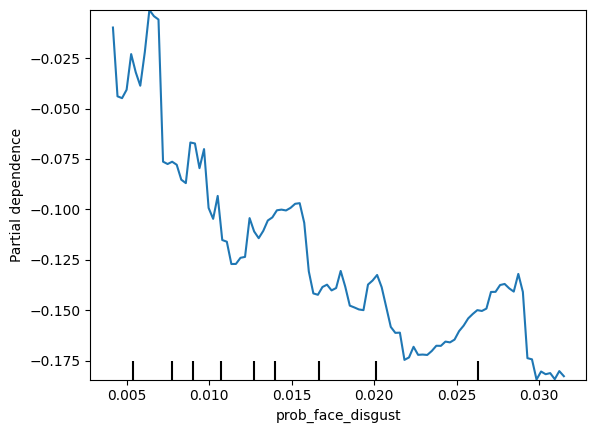

In [327]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(rf, X, ['prob_face_disgust'])
plt.show()


In [328]:
features = ["prob_face_neutral", "prob_face_sadness", "prob_face_disgust", "prob_face_fear", "prob_face_anger", "prob_face_happiness", "prob_face_contempt", "prob_face_surprise" ]

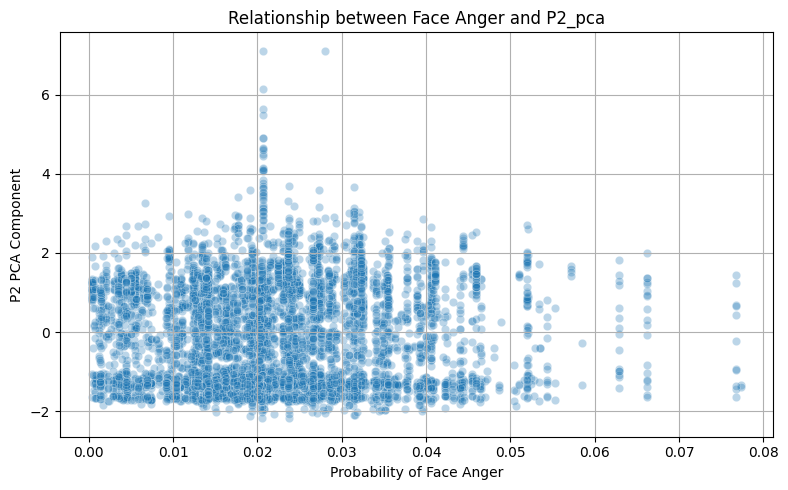

In [329]:
# Re-import necessary libraries after kernel reset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Simulate example data structure for the plot (replace with actual data in real usage)
# This is just to reinitialize after kernel reset
# Replace this with loading actual 'all_data' if available
import numpy as np
np.random.seed(0)

# Scatterplot of prob_face_anger vs P2_pca
plt.figure(figsize=(8, 5))
sns.scatterplot(x=all_data["prob_face_anger"], y=all_data["P2_pca"], alpha=0.3)
plt.xlabel("Probability of Face Anger")
plt.ylabel("P2 PCA Component")
plt.title("Relationship between Face Anger and P2_pca")
plt.grid(True)
plt.tight_layout()
plt.show()


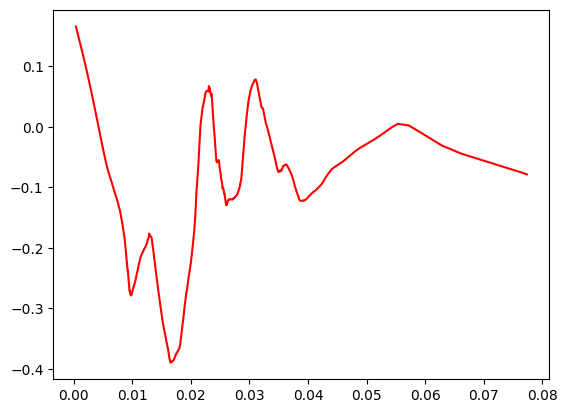

In [330]:
import statsmodels.api as sm
x = all_data["prob_face_anger"]
y = all_data["P2_pca"]
lowess = sm.nonparametric.lowess
z = lowess(y, x, frac=0.2)
plt.plot(z[:, 0], z[:, 1], color='red')

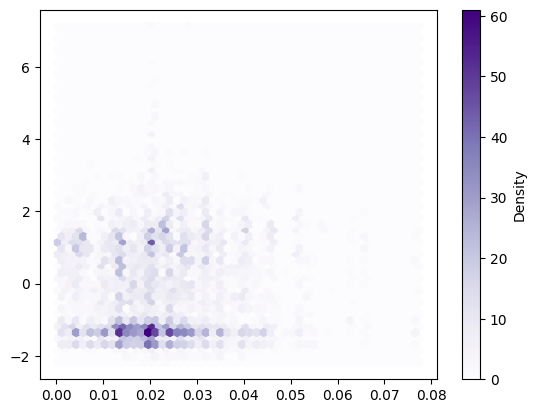

In [331]:
x = all_data["prob_face_anger"]
y = all_data["P2_pca"]
plt.hexbin(x, y, gridsize=50, cmap="Purples")
plt.colorbar(label="Density")


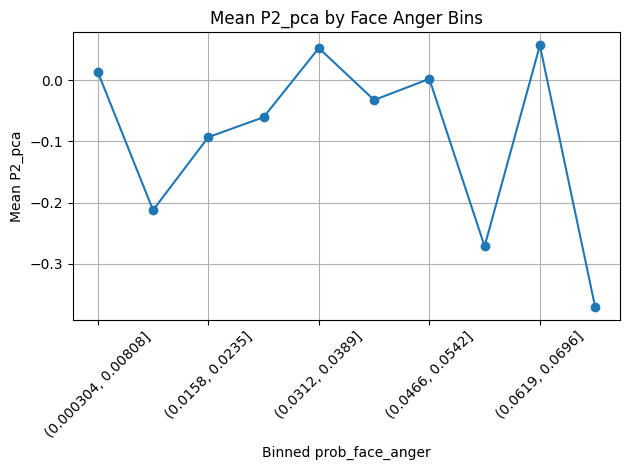

In [332]:
binned = pd.cut(all_data["prob_face_anger"], bins=10)
means = all_data.groupby(binned)["P2_pca"].mean()

# Plot
means.plot(marker='o', linestyle='-')
plt.xlabel("Binned prob_face_anger")
plt.ylabel("Mean P2_pca")
plt.title("Mean P2_pca by Face Anger Bins")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


<Axes: xlabel='prob_face_anger'>

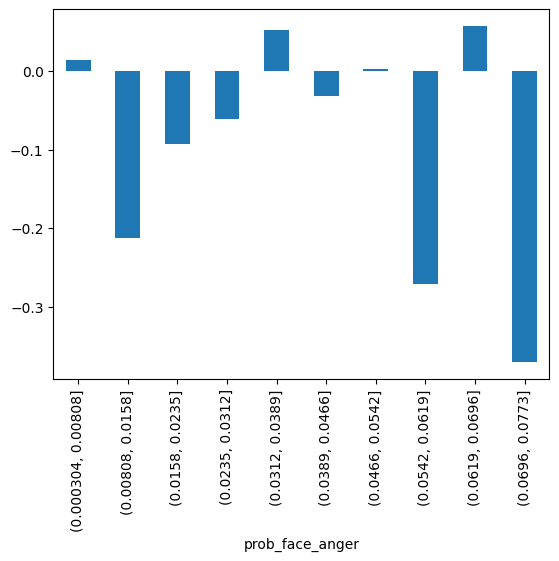

In [333]:
binned = pd.cut(all_data["prob_face_anger"], bins=10)
grouped = all_data.groupby(binned)["P2_pca"].mean()
grouped.plot(kind="bar")


R^2: 0.11597119475524109
MSE: 1.4345943741588565


/u/sebono/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning:

X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names



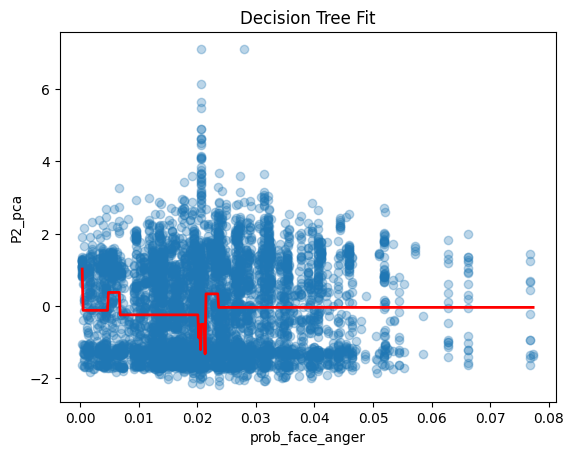

In [334]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Features and target
X = all_data[["prob_face_anger"]]  # or multiple features
y = all_data["P2_pca"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit tree
tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

# Predict and evaluate
y_pred = tree.predict(X_test)
print("R^2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# Plot the fit
import matplotlib.pyplot as plt
xx = np.linspace(X.min()[0], X.max()[0], 500).reshape(-1, 1)
yy = tree.predict(xx)
plt.scatter(X, y, alpha=0.3)
plt.plot(xx, yy, color="red", lw=2)
plt.xlabel("prob_face_anger")
plt.ylabel("P2_pca")
plt.title("Decision Tree Fit")
plt.show()


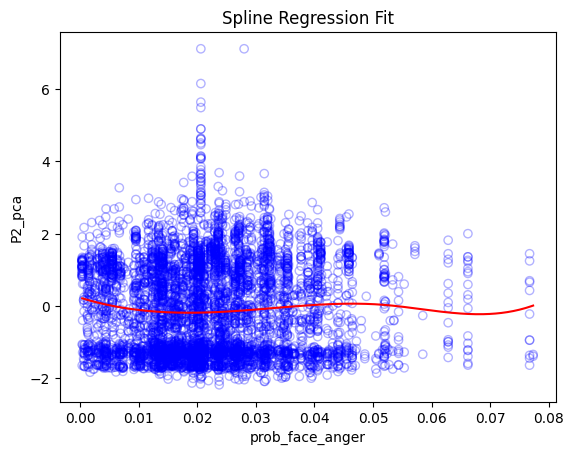

In [335]:
import statsmodels.api as sm
from patsy import dmatrix

# Generate spline basis for prob_face_anger
x_spline = dmatrix("bs(prob_face_anger, df=5, degree=3, include_intercept=False)", 
                   data=all_data, return_type='dataframe')

# Fit model
y = all_data["P2_pca"]
model = sm.OLS(y, x_spline).fit()

# Predict
x_pred = np.linspace(all_data["prob_face_anger"].min(), all_data["prob_face_anger"].max(), 300)
x_pred_spline = dmatrix("bs(x, df=5, degree=3, include_intercept=False)", 
                        {"x": x_pred}, return_type='dataframe')
y_pred = model.predict(x_pred_spline)

# Plot
plt.scatter(all_data["prob_face_anger"], y, facecolors='none', edgecolors='b', alpha=0.3)
plt.plot(x_pred, y_pred, color="red")
plt.xlabel("prob_face_anger")
plt.ylabel("P2_pca")
plt.title("Spline Regression Fit")
plt.show()


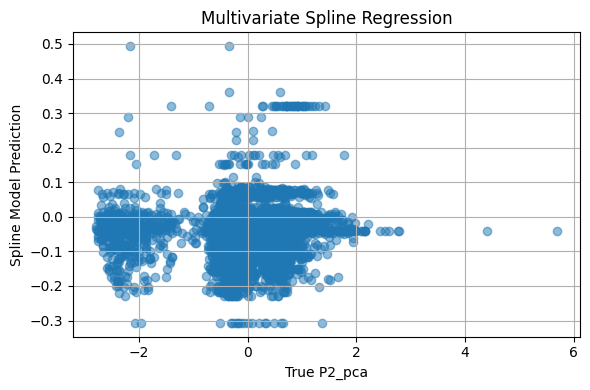

In [336]:
# Re-import necessary modules after kernel reset
import pandas as pd
import numpy as np
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Simulate minimal structure (replace this with actual `all_data`)
np.random.seed(0)
N = 500

# Features for GAM-like spline model
features = ["prob_face_anger", "prob_face_happiness"]
X = all_data[features]
y = all_data["P3_pca"]

# Multivariate spline regression via sklearn pipeline
spline_model = make_pipeline(
    SplineTransformer(degree=3, n_knots=5, include_bias=False),
    LinearRegression()
)
spline_model.fit(X, y)
spline_preds = spline_model.predict(X)

# Plot predictions vs true
plt.figure(figsize=(6, 4))
plt.scatter(y, spline_preds, alpha=0.5)
plt.xlabel("True P2_pca")
plt.ylabel("Spline Model Prediction")
plt.title("Multivariate Spline Regression")
plt.grid(True)
plt.tight_layout()
plt.show()


In [337]:
all_data

,token_id,P2_pca,P3_pca,prob_face_anger,prob_face_contempt,prob_face_disgust,prob_face_fear,prob_face_happiness,prob_face_neutral,prob_face_sadness,prob_face_surprise,smile
0,0,5.637913,5.689747,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
1,1,6.151982,4.408739,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
2,2,5.486775,2.770170,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
3,3,4.896356,1.832606,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
4,4,4.130875,1.370864,0.020627,0.010858,0.018534,0.145085,0.059267,0.244137,0.190081,0.311411,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5890,5042,-0.594527,-0.716070,0.014125,0.016255,0.024359,0.106858,0.194446,0.269486,0.147353,0.227117,0.0
5891,5042,-0.594527,-0.716070,0.016587,0.024803,0.018687,0.105825,0.220713,0.252812,0.155953,0.204621,0.0
5892,5043,-0.640108,-0.760311,0.016587,0.024803,0.018687,0.105825,0.220713,0.252812,0.155953,0.204621,0.0
5893,5044,0.132367,-2.759285,0.016587,0.024803,0.018687,0.105825,0.220713,0.252812,0.155953,0.204621,0.0


In [338]:
# Features and target
X = all_data[[
    "prob_face_anger", "prob_face_happiness", "prob_face_sadness",
    "prob_face_fear", "prob_face_disgust", "prob_face_surprise", "smile"
]]
y = all_data["P2_pca"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [339]:
from pygam import LinearGAM, s

gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6)).fit(X_train, y_train)
y_pred = gam.predict(X_test)

print("GAM R²:", r2_score(y_test, y_pred))

GAM R²: 0.06815114752746965


 97%|=================== | 1122/1156 [00:32<00:00]       

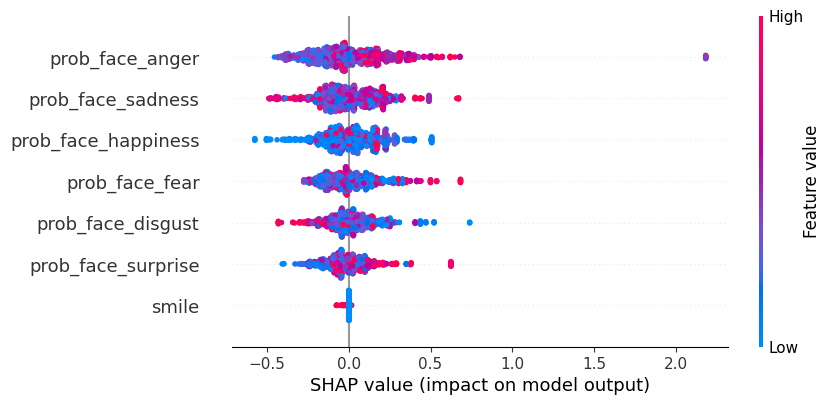

In [340]:
import shap
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor().fit(X_train, y_train)
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

In [341]:
# Features and target
X = all_data[[
    "prob_face_anger", "prob_face_happiness", "prob_face_sadness",
    "prob_face_fear", "prob_face_disgust", "prob_face_surprise", "smile"
]]
y = all_data["P3_pca"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


 97%|=================== | 1121/1156 [00:33<00:01]       

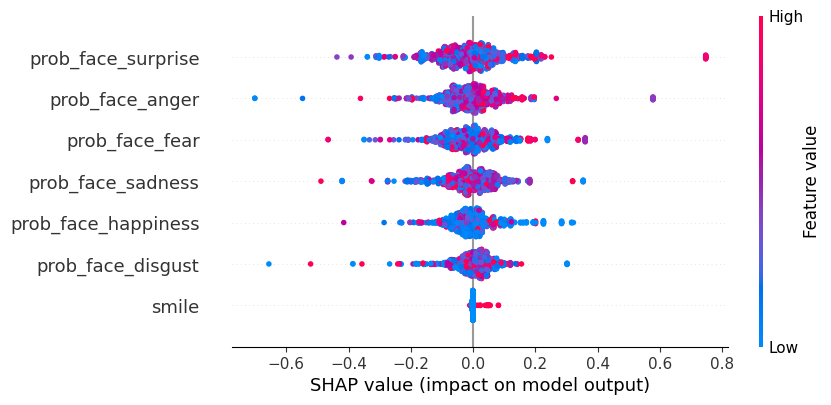

In [342]:
import shap
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor().fit(X_train, y_train)
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)